System Configuration: Device set to cuda
Total configurations to test: 490

GRID SEARCH RESULTS
     lookback  hidden_size  num_layers  batch_size  found_lr      mae     rmse       r2
0           1            8           1         128  0.015849 0.039674 0.045531 0.935959
1           1            8           2         128  0.015849 0.037427 0.043236 0.942251
2           1            8           3         128  0.019055 0.034772 0.041042 0.947964
3           1            8           4         128  0.019055 0.018119 0.024115 0.982035
4           1            8           5         128  0.015849 0.073798 0.078256 0.810814
..        ...          ...         ...         ...       ...      ...      ...      ...
485        60          512           6         128  0.000091 0.023592 0.030703 0.967272
486        60          512           7         128  0.000091 0.021856 0.028266 0.972259
487        60          512           8         128  0.000091 0.029033 0.035529 0.956172
488        60          5

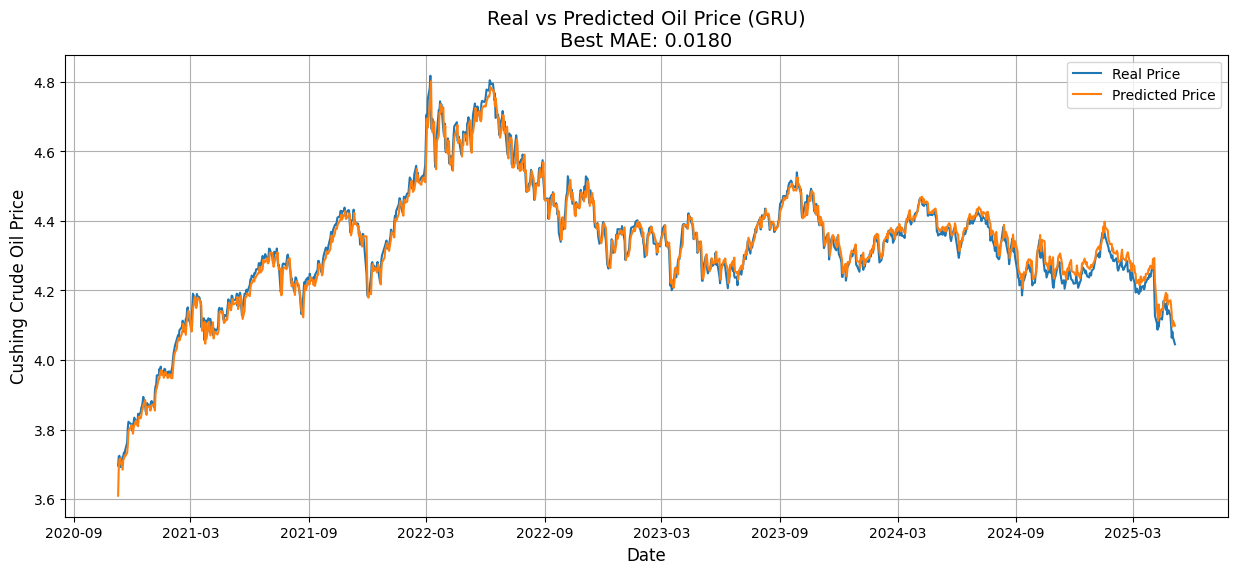

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import itertools
import copy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import os

warnings.filterwarnings("ignore", message=".*contiguous.*")
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(suppress=True)
pd.options.display.float_format = '{:.6f}'.format

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"System Configuration: Device set to {device}")

# --- Data Loading ---
df = pd.read_csv('compiled_dataset.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

feature_cols = [
    'dow_jones_adj_close_price',
    'nasdaq_adj_close_price',
    'sp_adj_close_price',
    'usd_to_uk_exchange_rate',
    'treasury_1_year_rate',
    'breakeven_inflation_5_year_rate',
    'bank_prime_loan_rate',
    'federal_funds_rate',
    'cushing_crude_oil_price',
]
target_col = 'cushing_crude_oil_price'

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
scaled_features = feature_scaler.fit_transform(df[feature_cols].values)
scaled_target = target_scaler.fit_transform(df[[target_col]].values)

def create_sequences(features_arr, target_arr, lookback):
    """Generates sliding window sequences (X) and targets (y)."""
    X_list, y_list = [], []
    for i in range(lookback, len(features_arr)):
        X_list.append(features_arr[i - lookback:i])
        y_list.append(target_arr[i])
    return np.array(X_list), np.array(y_list)

class GRURegressor(nn.Module):
    """GRU architecture with a linear regression head."""
    def __init__(self, input_size, hidden_size, num_layers):
        super(GRURegressor, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        self.gru.flatten_parameters() # Enforce memory contiguity to silence warnings
        out, _ = self.gru(x)
        out = out[:, -1, :] # Select last hidden state
        return self.fc(out)

def find_optimal_lr(model, train_loader, criterion, device):
    """Lightweight Learning Rate Range Test to suggest a starting LR."""
    model_copy = copy.deepcopy(model)
    model_copy.gru.flatten_parameters() # Explicit flatten for the copy
    
    optimizer = torch.optim.Adam(model_copy.parameters(), lr=1e-7)
    start_lr, end_lr = 1e-7, 10.0
    num_steps = 100
    gamma = (end_lr / start_lr) ** (1 / num_steps)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma)

    model_copy.train()
    lrs, losses = [], []
    avg_loss = 0.0
    best_loss = float('inf')
    iter_loader = itertools.cycle(train_loader)

    for i in range(num_steps):
        try:
            batch_X, batch_y = next(iter_loader)
        except StopIteration:
            break

        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model_copy(batch_X)
        loss = criterion(outputs, batch_y)

        # Smooth loss to filter noise
        avg_loss = loss.item() if i == 0 else 0.05 * loss.item() + 0.95 * avg_loss

        if i > 10 and avg_loss > 4 * best_loss:
            break

        best_loss = min(best_loss, avg_loss)
        lrs.append(optimizer.param_groups[0]['lr'])
        losses.append(avg_loss)

        loss.backward()
        optimizer.step()
        scheduler.step()

    lrs = np.array(lrs)
    losses = np.array(losses)
    if len(losses) < 2:
        return 0.001

    grads = losses[1:] - losses[:-1]
    optimal_lr = lrs[np.argmin(grads)]
    
    del model_copy
    return optimal_lr

# --- Grid Search Configuration ---
param_grid = {
    'lookback': [1, 3, 7, 14, 21, 30, 60],
    'hidden_size': [8, 16, 32, 64, 128, 256, 512],
    'num_layers': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
}
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
batch_size = 128

print(f"Total configurations to test: {len(combinations)}")
results = []

# --- Main Grid Search Loop ---
for i, params in enumerate(combinations):
    lookback = params['lookback']
    hidden_size = params['hidden_size']
    num_layers = params['num_layers']

    X, y = create_sequences(scaled_features, scaled_target, lookback)

    # Time-based split (80/20)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    input_size = X_train.shape[-1]
    model = GRURegressor(input_size, hidden_size, num_layers).to(device)
    criterion = nn.MSELoss()

    suggested_lr = find_optimal_lr(model, train_loader, criterion, device)
    suggested_lr = max(1e-5, min(suggested_lr, 0.1))
    optimizer = torch.optim.Adam(model.parameters(), lr=suggested_lr)

    num_epochs = 50

    # Training
    for _ in range(num_epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            y_pred_list.append(outputs.cpu().numpy())

    y_pred_scaled = np.concatenate(y_pred_list)
    y_pred = target_scaler.inverse_transform(y_pred_scaled)
    y_test_real = target_scaler.inverse_transform(y_test)

    mae = mean_absolute_error(y_test_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
    r2 = r2_score(y_test_real, y_pred)

    results.append({
        'lookback': lookback,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'batch_size': batch_size,
        'found_lr': float(f"{suggested_lr:.6f}"),
        'mae': mae,
        'rmse': rmse,
        'r2': r2
    })

results_df = pd.DataFrame(results)

# --- Reporting & Plotting ---
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n" + "="*80)
print("GRID SEARCH RESULTS")
print("="*80)
print(results_df)

print("\n" + "="*80)
print("BEST MODEL CONFIGURATION (Lowest MAE)")
print("="*80)

if not results_df.empty:
    best_result = results_df.loc[results_df['mae'].idxmin()]
    print(best_result)
    
    # Retrain best model specifically for plotting
    best_lookback = int(best_result['lookback'])
    best_hidden = int(best_result['hidden_size'])
    best_layers = int(best_result['num_layers'])
    best_lr = float(best_result['found_lr'])
    
    print("\nRetraining best model for plotting...")
    
    X, y = create_sequences(scaled_features, scaled_target, best_lookback)
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    model = GRURegressor(X_train.shape[-1], best_hidden, best_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
    criterion = nn.MSELoss()
    
    for _ in range(50):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    y_pred_list = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            y_pred_list.append(outputs.cpu().numpy())
            
    y_pred_final = target_scaler.inverse_transform(np.concatenate(y_pred_list))
    y_real_final = target_scaler.inverse_transform(y_test)
    
    # Visualization
    test_dates = df['Date'].iloc[best_lookback + train_size:].reset_index(drop=True)
    
    plt.figure(figsize=(15, 6))
    plt.plot(test_dates, y_real_final, label='Real Price', color='#1f77b4')
    plt.plot(test_dates, y_pred_final, label='Predicted Price', color='#ff7f0e')
    
    plt.title(f'Real vs Predicted Oil Price (GRU)\nBest MAE: {best_result["mae"]:.4f}', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Cushing Crude Oil Price', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.show()

else:
    print("No results generated.")

In [3]:
print(best_result)

lookback        1.000000
hidden_size    32.000000
num_layers      2.000000
batch_size    128.000000
found_lr        0.007586
mae             0.018011
rmse            0.024176
r2              0.981945
Name: 21, dtype: float64
